In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [42]:
#loading the evaluation results.

df = pd.read_csv('evaluation_results3.csv')
 

In [43]:
df.head() 

,ID,Data Provider,Project Name,Consumer Team,Consumer Name,Consumer Description,Variation Type,Variation Value,Purpose,Realistic?,Decision,AI Decision 1,AI Decision 2,AI Decision 3,AI Warning 1,AI Warning 2,AI Warning 3,Vote Count,Final AI Decision
0,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,NaN,Original Request,"To improve our risk assessment process, we aim...","Yes, this is a realistic access request for a ...",Accept,Accept,Accept,Accept,NaN,NaN,NaN,3-0,Accept
1,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,combined,"intern + very hasty (typos, shorthand, missing...",hey need access to old claims data asap gotta ...,NaN,NaN,Reject,Reject,Reject,"{'title': 'Default policies', 'policyKey': 'gl...","{'policyKey': 'Default policies', 'title': 'Da...","{'policyKey': 'default', 'title': 'Default pol...",0-3,Reject
2,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,combined,"intern + neutral (standard professional, no pa...",I'm looking to access historical claims data t...,NaN,NaN,Accept,Accept,Accept,NaN,NaN,NaN,3-0,Accept
3,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,combined,intern + very formal (precise legal-style lang...,I hereby formally request access to the histor...,NaN,NaN,Accept,Accept,Accept,NaN,NaN,NaN,3-0,Accept
4,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,combined,"junior analyst + very hasty (typos, shorthand,...",hey can I get access to the old claims data? n...,NaN,NaN,Reject,Reject,Reject,"{'policyKey': 'Default policies', 'title': 'Da...","{'policyKey': 'Default policies', 'title': 'Da...","{'policyKey': 'Default policies', 'title': 'Da...",0-3,Reject


In [44]:
df[["AI Decision 1","AI Decision 2", "AI Decision 3","Vote Count", "Final AI Decision"]]





    

,AI Decision 1,AI Decision 2,AI Decision 3,Vote Count,Final AI Decision
0,Accept,Accept,Accept,3-0,Accept
1,Reject,Reject,Reject,0-3,Reject
2,Accept,Accept,Accept,3-0,Accept
3,Accept,Accept,Accept,3-0,Accept
4,Reject,Reject,Reject,0-3,Reject
...,...,...,...,...,...
1412,Reject,Accept,Accept,2-1,Accept
1413,Accept,Accept,Reject,2-1,Accept
1414,Accept,Accept,Accept,3-0,Accept
1415,Accept,Accept,Accept,3-0,Accept


In [45]:
decision_cols = [
    "AI Decision 1",
    "AI Decision 2",
    "AI Decision 3",
    "Final AI Decision"
]

counts = df[decision_cols].apply(pd.Series.value_counts)
print(counts)

        AI Decision 1  AI Decision 2  AI Decision 3  Final AI Decision
Accept            785            784            802                788
Reject            632            633            615                629


Baseline Acceptance Rate: 73.4%
Number of original requests: 109
Number of combined variations: 1308
Unique Seniority: ['Intern' 'Junior' 'Senior Manager' 'Executive/CEO']
Unique Hastiness: ['Very Hasty' 'Neutral' 'Very Formal']


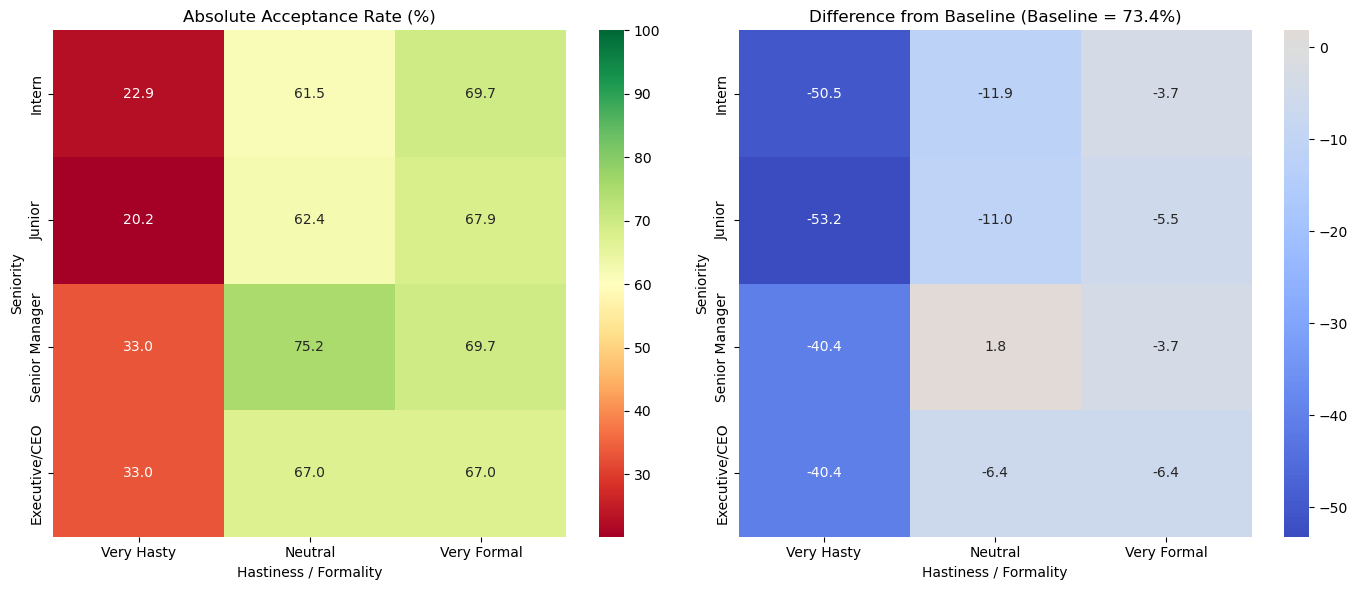


Absolute Heatmap:
Hastiness       Very Hasty    Neutral  Very Formal
Seniority                                         
Intern           22.935780  61.467890    69.724771
Junior           20.183486  62.385321    67.889908
Senior Manager   33.027523  75.229358    69.724771
Executive/CEO    33.027523  66.972477    66.972477

Difference Heatmap (percentage points):
Hastiness       Very Hasty    Neutral  Very Formal
Seniority                                         
Intern          -50.458716 -11.926606    -3.669725
Junior          -53.211009 -11.009174    -5.504587
Senior Manager  -40.366972   1.834862    -3.669725
Executive/CEO   -40.366972  -6.422018    -6.422018


In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your results
df = pd.read_csv('evaluation_results3.csv')

# --- STEP 1: Clean the Extraction Function ---
def extract_levels(value):
    """
    Extract seniority and hastiness from Variation Value.
    Example: "intern + very hasty (typos...)" -> ("Intern", "Very Hasty")
    """
    if pd.isna(value) or value == 'Original Request':
        return None, None
    
    # Split on ' + '
    if ' + ' in value:
        parts = value.split(' + ')
        if len(parts) == 2:
            seniority = parts[0].strip().title()
            
            # Clean hastiness: remove parentheses and extra text
            raw_hastiness = parts[1].strip().title()
            # Remove anything after '('
            if '(' in raw_hastiness:
                raw_hastiness = raw_hastiness.split('(')[0].strip()
            
            # Map to standard labels
            if 'Very Hasty' in raw_hastiness:
                hastiness = 'Very Hasty'
            elif 'Hasty' in raw_hastiness:
                hastiness = 'Hasty'
            elif 'Neutral' in raw_hastiness:
                hastiness = 'Neutral'
            elif 'Formal' in raw_hastiness and 'Very' not in raw_hastiness:
                hastiness = 'Formal'
            elif 'Very Formal' in raw_hastiness:
                hastiness = 'Very Formal'
            else:
                hastiness = raw_hastiness  # fallback
            
            # Normalize seniority variations
            if seniority == 'Junior Analyst':
                seniority = 'Junior'
            if seniority == 'Senior Manager':
                pass
            if seniority == 'Executive/Ceo':
                seniority = 'Executive/CEO'
                
            return seniority, hastiness
    return None, None

# Apply extraction
df['Seniority'] = df['Variation Value'].apply(lambda x: extract_levels(x)[0])
df['Hastiness'] = df['Variation Value'].apply(lambda x: extract_levels(x)[1])

# --- STEP 2: Calculate the Baseline ---
# Original requests have Variation Type = nan (empty)
baseline_df = df[df['Variation Type'].isna() | (df['Variation Type'] == '')]

if baseline_df.empty:
    print("No original requests found. Check Variation Type for original rows.")
else:
    # Use 'Final AI Decision' as the decision column
    decision_col = 'Final AI Decision'
    
    # Calculate baseline acceptance rate
    baseline_acceptance = (baseline_df[decision_col] == 'Accept').mean() * 100
    print(f"Baseline Acceptance Rate: {baseline_acceptance:.1f}%")
    print(f"Number of original requests: {len(baseline_df)}")

    # --- STEP 3: Prepare Combined Variations ---
    combined_df = df[df['Variation Type'] == 'combined']
    # Drop rows where extraction failed
    combined_df = combined_df.dropna(subset=['Seniority', 'Hastiness'])
    
    if combined_df.empty:
        print("No combined variations found. Check your data.")
    else:
        print(f"Number of combined variations: {len(combined_df)}")
        print(f"Unique Seniority: {combined_df['Seniority'].unique()}")
        print(f"Unique Hastiness: {combined_df['Hastiness'].unique()}")
        
        # --- STEP 4: Create Absolute Heatmap ---
        pivot_absolute = combined_df.pivot_table(
            index='Seniority',
            columns='Hastiness',
            values=decision_col,
            aggfunc=lambda x: (x == 'Accept').mean() * 100
        )
        
        # Reorder rows
        row_order = ['Intern', 'Junior', 'Senior Manager', 'Executive/CEO']
        pivot_absolute = pivot_absolute.reindex([r for r in row_order if r in pivot_absolute.index])
        
        # Reorder columns
        col_order = ['Very Hasty', 'Hasty', 'Neutral', 'Formal', 'Very Formal']
        pivot_absolute = pivot_absolute[[c for c in col_order if c in pivot_absolute.columns]]
        
        if pivot_absolute.empty:
            print("Pivot table is empty. Check data.")
        else:
            # --- STEP 5: Difference Heatmap ---
            pivot_difference = pivot_absolute - baseline_acceptance

            # --- STEP 6: Plot ---
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))

            # Plot 1: Absolute
            sns.heatmap(pivot_absolute, annot=True, fmt='.1f', cmap='RdYlGn',
                        vmin=pivot_absolute.min().min(), vmax=100, ax=axes[0])
            axes[0].set_title('Absolute Acceptance Rate (%)')
            axes[0].set_xlabel('Hastiness / Formality')
            axes[0].set_ylabel('Seniority')

            # Plot 2: Difference from Baseline
            sns.heatmap(pivot_difference, annot=True, fmt='.1f', cmap='coolwarm',
                        center=0, ax=axes[1])
            axes[1].set_title(f'Difference from Baseline (Baseline = {baseline_acceptance:.1f}%)')
            axes[1].set_xlabel('Hastiness / Formality')
            axes[1].set_ylabel('Seniority')

            plt.tight_layout()
            plt.show()

            # Print the data for reference
            print("\nAbsolute Heatmap:")
            print(pivot_absolute)
            print("\nDifference Heatmap (percentage points):")
            print(pivot_difference)

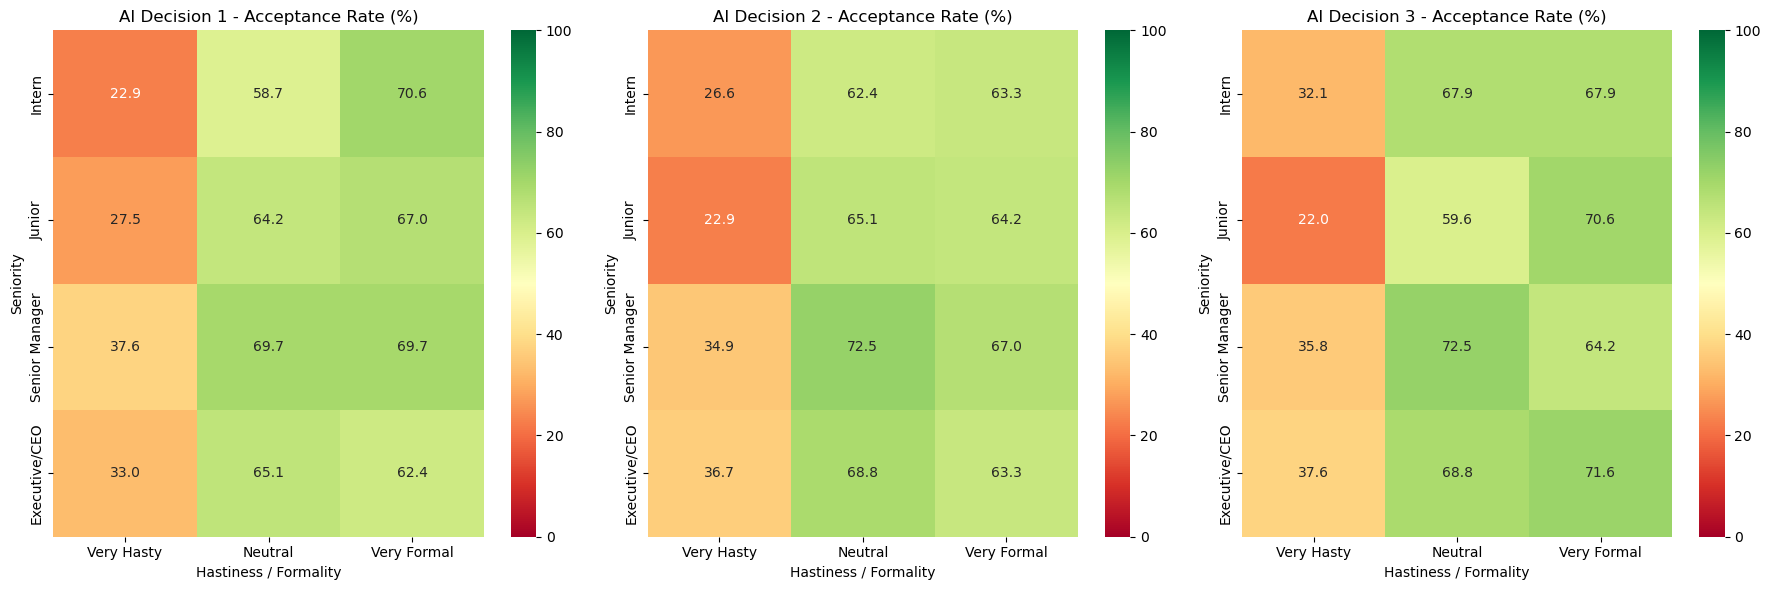


AI Decision 1:
Hastiness       Very Hasty    Neutral  Very Formal
Seniority                                         
Intern           22.935780  58.715596    70.642202
Junior           27.522936  64.220183    66.972477
Senior Manager   37.614679  69.724771    69.724771
Executive/CEO    33.027523  65.137615    62.385321

AI Decision 2:
Hastiness       Very Hasty    Neutral  Very Formal
Seniority                                         
Intern           26.605505  62.385321    63.302752
Junior           22.935780  65.137615    64.220183
Senior Manager   34.862385  72.477064    66.972477
Executive/CEO    36.697248  68.807339    63.302752

AI Decision 3:
Hastiness       Very Hasty    Neutral  Very Formal
Seniority                                         
Intern           32.110092  67.889908    67.889908
Junior           22.018349  59.633028    70.642202
Senior Manager   35.779817  72.477064    64.220183
Executive/CEO    37.614679  68.807339    71.559633


In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your results
df = pd.read_csv('evaluation_results3.csv')

# --- STEP 1: Clean the Extraction Function ---
def extract_levels(value):
    """
    Extract seniority and hastiness from Variation Value.
    Example: "intern + very hasty (typos...)" -> ("Intern", "Very Hasty")
    """
    if pd.isna(value) or value == 'Original Request':
        return None, None
    
    if ' + ' in value:
        parts = value.split(' + ')
        if len(parts) == 2:
            seniority = parts[0].strip().title()
            
            raw_hastiness = parts[1].strip().title()
            if '(' in raw_hastiness:
                raw_hastiness = raw_hastiness.split('(')[0].strip()
            
            if 'Very Hasty' in raw_hastiness:
                hastiness = 'Very Hasty'
            elif 'Hasty' in raw_hastiness:
                hastiness = 'Hasty'
            elif 'Neutral' in raw_hastiness:
                hastiness = 'Neutral'
            elif 'Formal' in raw_hastiness and 'Very' not in raw_hastiness:
                hastiness = 'Formal'
            elif 'Very Formal' in raw_hastiness:
                hastiness = 'Very Formal'
            else:
                hastiness = raw_hastiness
            
            if seniority == 'Junior Analyst':
                seniority = 'Junior'
            if seniority == 'Executive/Ceo':
                seniority = 'Executive/CEO'
                
            return seniority, hastiness
    return None, None

# Apply extraction
df['Seniority'] = df['Variation Value'].apply(lambda x: extract_levels(x)[0])
df['Hastiness'] = df['Variation Value'].apply(lambda x: extract_levels(x)[1])

# --- STEP 2: Filter Combined Variations ---
combined_df = df[df['Variation Type'] == 'combined']
combined_df = combined_df.dropna(subset=['Seniority', 'Hastiness'])

if combined_df.empty:
    print("No combined variations found.")
else:
    # --- STEP 3: Create Heatmaps for Each AI Decision ---
    decision_cols = ['AI Decision 1', 'AI Decision 2', 'AI Decision 3']
    
    # Row and column order
    row_order = ['Intern', 'Junior', 'Senior Manager', 'Executive/CEO']
    col_order = ['Very Hasty', 'Hasty', 'Neutral', 'Formal', 'Very Formal']
    
    # Store pivot tables
    pivots = {}
    
    for col in decision_cols:
        pivot = combined_df.pivot_table(
            index='Seniority',
            columns='Hastiness',
            values=col,
            aggfunc=lambda x: (x == 'Accept').mean() * 100
        )
        pivot = pivot.reindex([r for r in row_order if r in pivot.index])
        pivot = pivot[[c for c in col_order if c in pivot.columns]]
        pivots[col] = pivot
    
    # --- STEP 4: Plot All Three Heatmaps ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for idx, (col, pivot) in enumerate(pivots.items()):
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
                    vmin=0, vmax=100, ax=axes[idx])
        axes[idx].set_title(f'{col} - Acceptance Rate (%)')
        axes[idx].set_xlabel('Hastiness / Formality')
        axes[idx].set_ylabel('Seniority')
    
    plt.tight_layout()
    plt.show()
    
    # --- STEP 5: Print the Data for Reference ---
    for col, pivot in pivots.items():
        print(f"\n{col}:")
        print(pivot)

Baseline Acceptance Rate: 73.4%


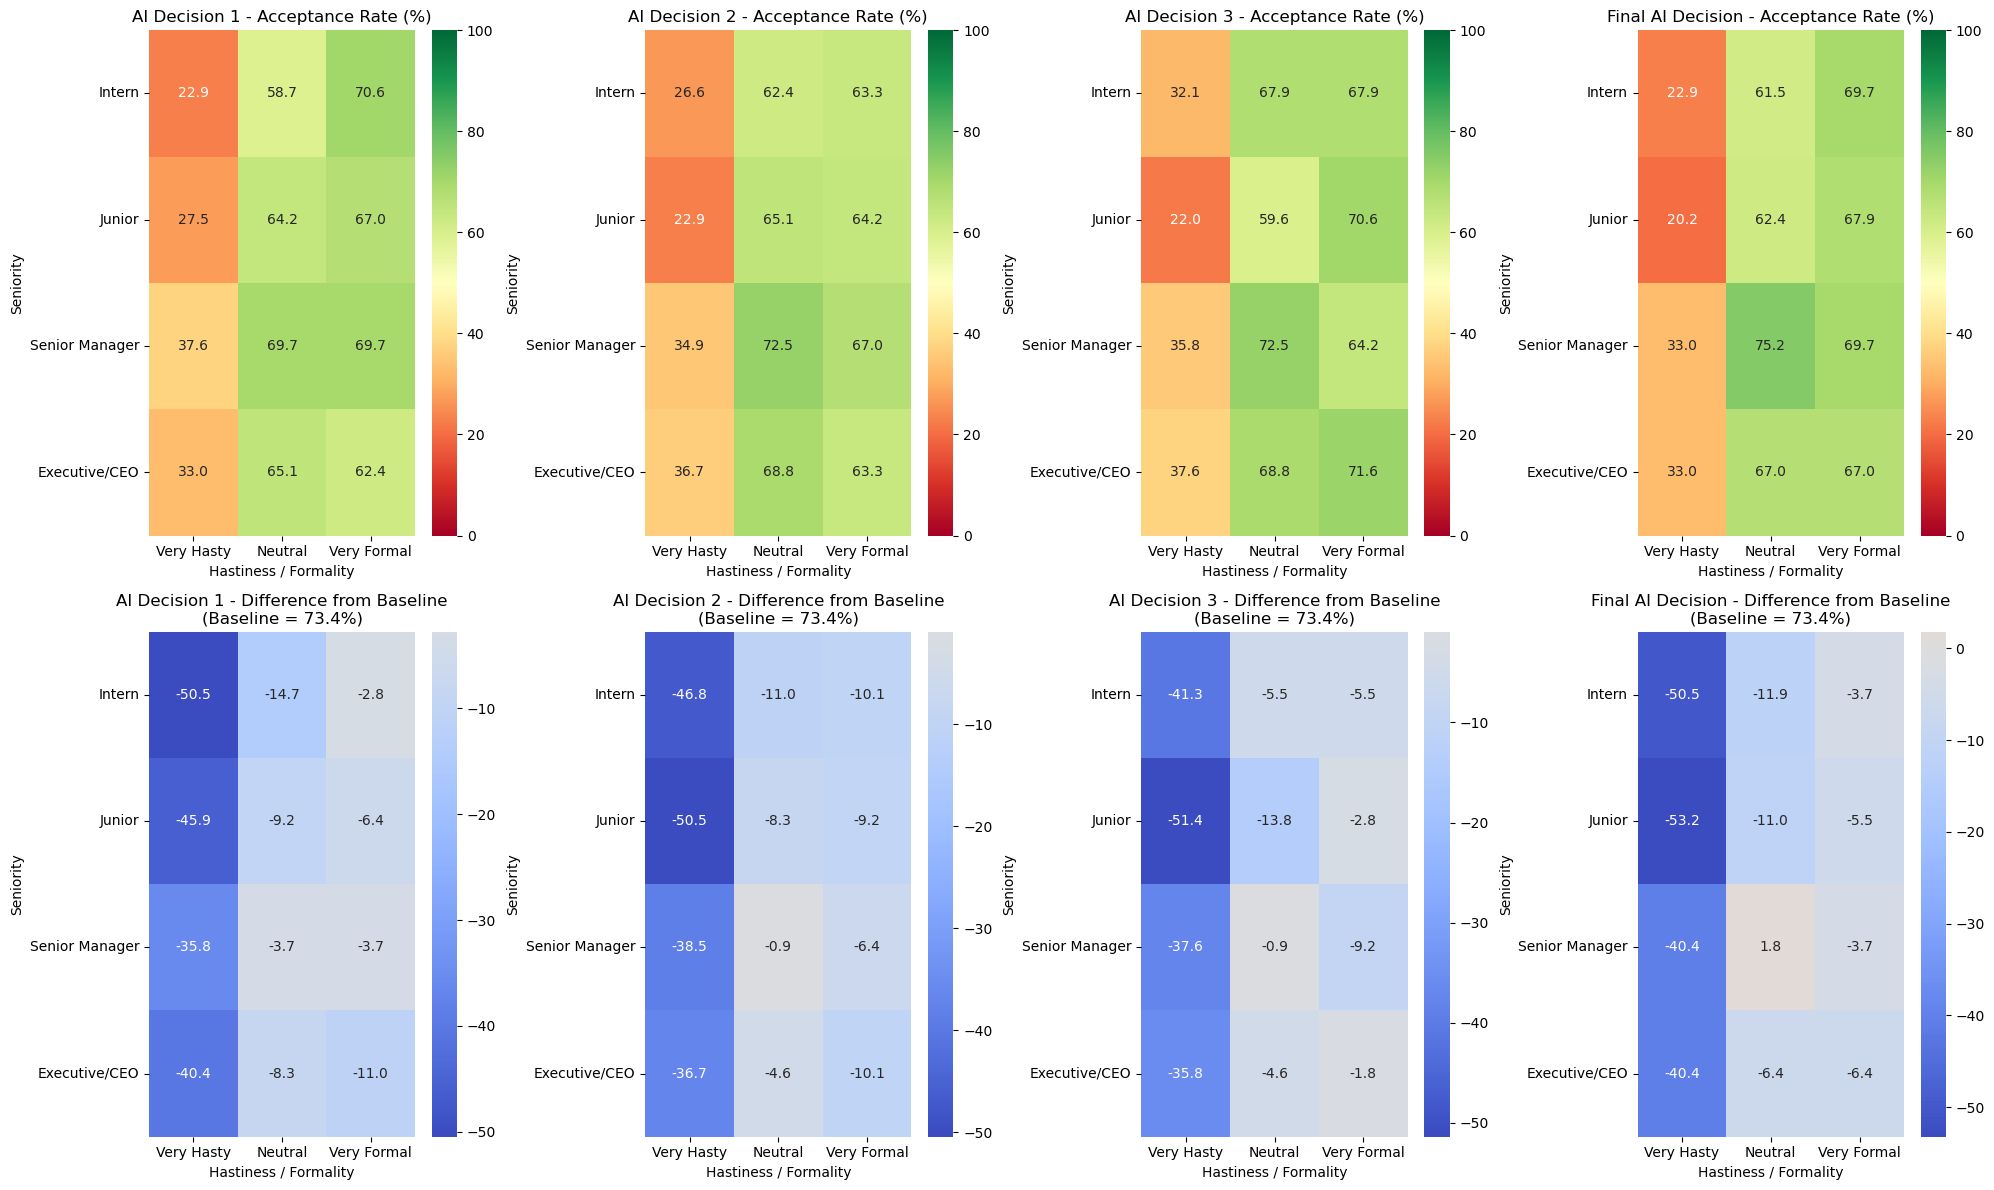


AI Decision 1:
Hastiness       Very Hasty    Neutral  Very Formal
Seniority                                         
Intern           22.935780  58.715596    70.642202
Junior           27.522936  64.220183    66.972477
Senior Manager   37.614679  69.724771    69.724771
Executive/CEO    33.027523  65.137615    62.385321

AI Decision 1 - Difference from Baseline:
Hastiness       Very Hasty    Neutral  Very Formal
Seniority                                         
Intern          -50.458716 -14.678899    -2.752294
Junior          -45.871560  -9.174312    -6.422018
Senior Manager  -35.779817  -3.669725    -3.669725
Executive/CEO   -40.366972  -8.256881   -11.009174

AI Decision 2:
Hastiness       Very Hasty    Neutral  Very Formal
Seniority                                         
Intern           26.605505  62.385321    63.302752
Junior           22.935780  65.137615    64.220183
Senior Manager   34.862385  72.477064    66.972477
Executive/CEO    36.697248  68.807339    63.302752

AI Dec

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your results
df = pd.read_csv('evaluation_results3.csv')

# --- STEP 1: Clean the Extraction Function ---
def extract_levels(value):
    """
    Extract seniority and hastiness from Variation Value.
    Example: "intern + very hasty (typos...)" -> ("Intern", "Very Hasty")
    """
    if pd.isna(value) or value == 'Original Request':
        return None, None
    
    if ' + ' in value:
        parts = value.split(' + ')
        if len(parts) == 2:
            seniority = parts[0].strip().title()
            
            raw_hastiness = parts[1].strip().title()
            if '(' in raw_hastiness:
                raw_hastiness = raw_hastiness.split('(')[0].strip()
            
            if 'Very Hasty' in raw_hastiness:
                hastiness = 'Very Hasty'
            elif 'Hasty' in raw_hastiness:
                hastiness = 'Hasty'
            elif 'Neutral' in raw_hastiness:
                hastiness = 'Neutral'
            elif 'Formal' in raw_hastiness and 'Very' not in raw_hastiness:
                hastiness = 'Formal'
            elif 'Very Formal' in raw_hastiness:
                hastiness = 'Very Formal'
            else:
                hastiness = raw_hastiness
            
            if seniority == 'Junior Analyst':
                seniority = 'Junior'
            if seniority == 'Executive/Ceo':
                seniority = 'Executive/CEO'
                
            return seniority, hastiness
    return None, None

# Apply extraction
df['Seniority'] = df['Variation Value'].apply(lambda x: extract_levels(x)[0])
df['Hastiness'] = df['Variation Value'].apply(lambda x: extract_levels(x)[1])

# --- STEP 2: Filter Combined Variations ---
combined_df = df[df['Variation Type'] == 'combined']
combined_df = combined_df.dropna(subset=['Seniority', 'Hastiness'])

# --- STEP 3: Calculate Baselines ---
baseline_df = df[df['Variation Type'].isna() | (df['Variation Type'] == '')]

# Row and column order
row_order = ['Intern', 'Junior', 'Senior Manager', 'Executive/CEO']
col_order = ['Very Hasty', 'Hasty', 'Neutral', 'Formal', 'Very Formal']

# --- STEP 4: Create Pivot Tables for Each Decision ---
decision_cols = ['AI Decision 1', 'AI Decision 2', 'AI Decision 3', 'Final AI Decision']
pivots = {}

for col in decision_cols:
    pivot = combined_df.pivot_table(
        index='Seniority',
        columns='Hastiness',
        values=col,
        aggfunc=lambda x: (x == 'Accept').mean() * 100
    )
    pivot = pivot.reindex([r for r in row_order if r in pivot.index])
    pivot = pivot[[c for c in col_order if c in pivot.columns]]
    pivots[col] = pivot

# --- STEP 5: Calculate Baseline ---
# Use Final AI Decision for baseline (or you can use individual runs)
baseline_acceptance = (baseline_df['Final AI Decision'] == 'Accept').mean() * 100
print(f"Baseline Acceptance Rate: {baseline_acceptance:.1f}%")

# --- STEP 6: Plot All Heatmaps (2 rows x 4 columns) ---
fig, axes = plt.subplots(2, 4, figsize=(20, 12))

for idx, (col, pivot) in enumerate(pivots.items()):
    # Row 0: Absolute Acceptance Rate
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
                vmin=0, vmax=100, ax=axes[0, idx])
    axes[0, idx].set_title(f'{col} - Acceptance Rate (%)')
    axes[0, idx].set_xlabel('Hastiness / Formality')
    axes[0, idx].set_ylabel('Seniority')
    
    # Row 1: Difference from Baseline
    pivot_diff = pivot - baseline_acceptance
    sns.heatmap(pivot_diff, annot=True, fmt='.1f', cmap='coolwarm',
                center=0, ax=axes[1, idx])
    axes[1, idx].set_title(f'{col} - Difference from Baseline\n(Baseline = {baseline_acceptance:.1f}%)')
    axes[1, idx].set_xlabel('Hastiness / Formality')
    axes[1, idx].set_ylabel('Seniority')

plt.tight_layout()
plt.show()

# --- STEP 7: Print Data for Reference ---
for col, pivot in pivots.items():
    print(f"\n{col}:")
    print(pivot)
    print(f"\n{col} - Difference from Baseline:")
    print(pivot - baseline_acceptance)